# Wine Shop & Delicatessen — Exploratory Data Analysis

**Course:** Advanced Programming with Python — Session 3 (Visualization)  
**Case:** Data Mining Case Study — Wine shop & delicatessen

**Goal of the assignment:** identify customer behavior patterns from a survey of 404 customers so the store can deliver a more personalized service and rebalance its perception (currently seen more as a wine shop than a delicatessen).

**This notebook** is a first-pass EDA: every univariate, bivariate, and a few multivariate views of the data, kept simple so a *Run All* produces every chart without errors.

## Variables
| Column | Type | Notes |
|---|---|---|
| `ID` | int | survey respondent id |
| `Wine frequency consumption` | categorical | 6 levels |
| `Payment mode` | categorical | Cash / Credit / Debit |
| `Place to drink` | categorical | 7 levels |
| `Additional products` | categorical | 8 deli products |
| `Gender` | categorical | Male / Female |
| `Education` | categorical | 9+ levels (some dirty) |
| `Age` | categorical (bins) | 4 levels |
| `Ticket` | numeric (€) | basket value |

## 1. Setup & Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13

df = pd.read_excel('5. Wine consumption.xlsx', sheet_name='Hoja1')
print('Shape:', df.shape)
df.head()

Shape: (404, 9)


,ID,Wine frequency consumption,Payment mode,Place to drink,Additional products,Gender,Education,Age,Ticket
0,1,1 to 2 times per week,Debit card,Parties,Cheese,Male,Secondary,31 to 40,66
1,2,Once per month,Credit card,Parties,Chocolate,Male,Technical Superior Unfinished,23 to 30,13
2,3,1 to 2 times per week,Credit card,Parties,Cheese,Female,Universitary Degree,31 to 40,10
3,4,Once per month,Cash,Home,Olives,Male,Postgraduate,41 to 50,19
4,5,1 to 2 times per week,Debit card,Parties,Olives,Female,Technical Superior,31 to 40,87


## 2. Quick data quality check

In [2]:
print('--- dtypes ---')
print(df.dtypes)
print('\n--- missing ---')
print(df.isna().sum())
print('\n--- duplicates on ID ---', df['ID'].duplicated().sum())
df.describe(include='all').T

--- dtypes ---
ID                             int64
Wine frequency consumption    object
Payment mode                  object
Place to drink                object
Additional products           object
Gender                        object
Education                     object
Age                           object
Ticket                         int64
dtype: object

--- missing ---
ID                            0
Wine frequency consumption    0
Payment mode                  0
Place to drink                0
Additional products           0
Gender                        0
Education                     0
Age                           0
Ticket                        0
dtype: int64

--- duplicates on ID --- 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,404.0,NaN,NaN,NaN,202.5,116.769003,1.0,101.75,202.5,303.25,404.0
Wine frequency consumption,404,6,1 to 2 times per week,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment mode,404,3,Cash,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Place to drink,404,7,Parties,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additional products,404,8,Olives,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,404,2,Male,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,404,10,Universitary Degree,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,404,4,31 to 40,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket,404.0,NaN,NaN,NaN,55.69802,26.949966,10.0,32.75,56.5,79.0,100.0


In [3]:
# Light cleanup: there's a single odd Education value '1'. Coerce to NaN for plots.
df['Education'] = df['Education'].replace({1: np.nan, '1': np.nan})

# Order categoricals so charts read left-to-right naturally.
freq_order = ['Once per month', 'More than once per month',
              '1 to 2 times per week', '3 to 4 times per week',
              '5 to 6 times per week', 'Once per day']
age_order  = ['23 to 30', '31 to 40', '41 to 50', 'more than 50']
edu_order  = ['Primary', 'Secondary Unfinished', 'Secondary',
              'Technical Superior Unfinished', 'Technical Superior',
              'Universitary Degree Unfinished', 'Universitary Degree',
              'Postgraduate Unfinished', 'Postgraduate']

df['Wine frequency consumption'] = pd.Categorical(df['Wine frequency consumption'], categories=freq_order, ordered=True)
df['Age']       = pd.Categorical(df['Age'], categories=age_order, ordered=True)
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

cat_cols = ['Wine frequency consumption', 'Payment mode', 'Place to drink',
            'Additional products', 'Gender', 'Education', 'Age']
num_cols = ['Ticket']
df.head()

,ID,Wine frequency consumption,Payment mode,Place to drink,Additional products,Gender,Education,Age,Ticket
0,1,1 to 2 times per week,Debit card,Parties,Cheese,Male,NaN,31 to 40,66
1,2,Once per month,Credit card,Parties,Chocolate,Male,Technical Superior Unfinished,23 to 30,13
2,3,1 to 2 times per week,Credit card,Parties,Cheese,Female,Universitary Degree,31 to 40,10
3,4,Once per month,Cash,Home,Olives,Male,Postgraduate,41 to 50,19
4,5,1 to 2 times per week,Debit card,Parties,Olives,Female,Technical Superior,31 to 40,87


## 3. Univariate — Categorical features
Count of customers per category. Quick sense of which categories dominate.

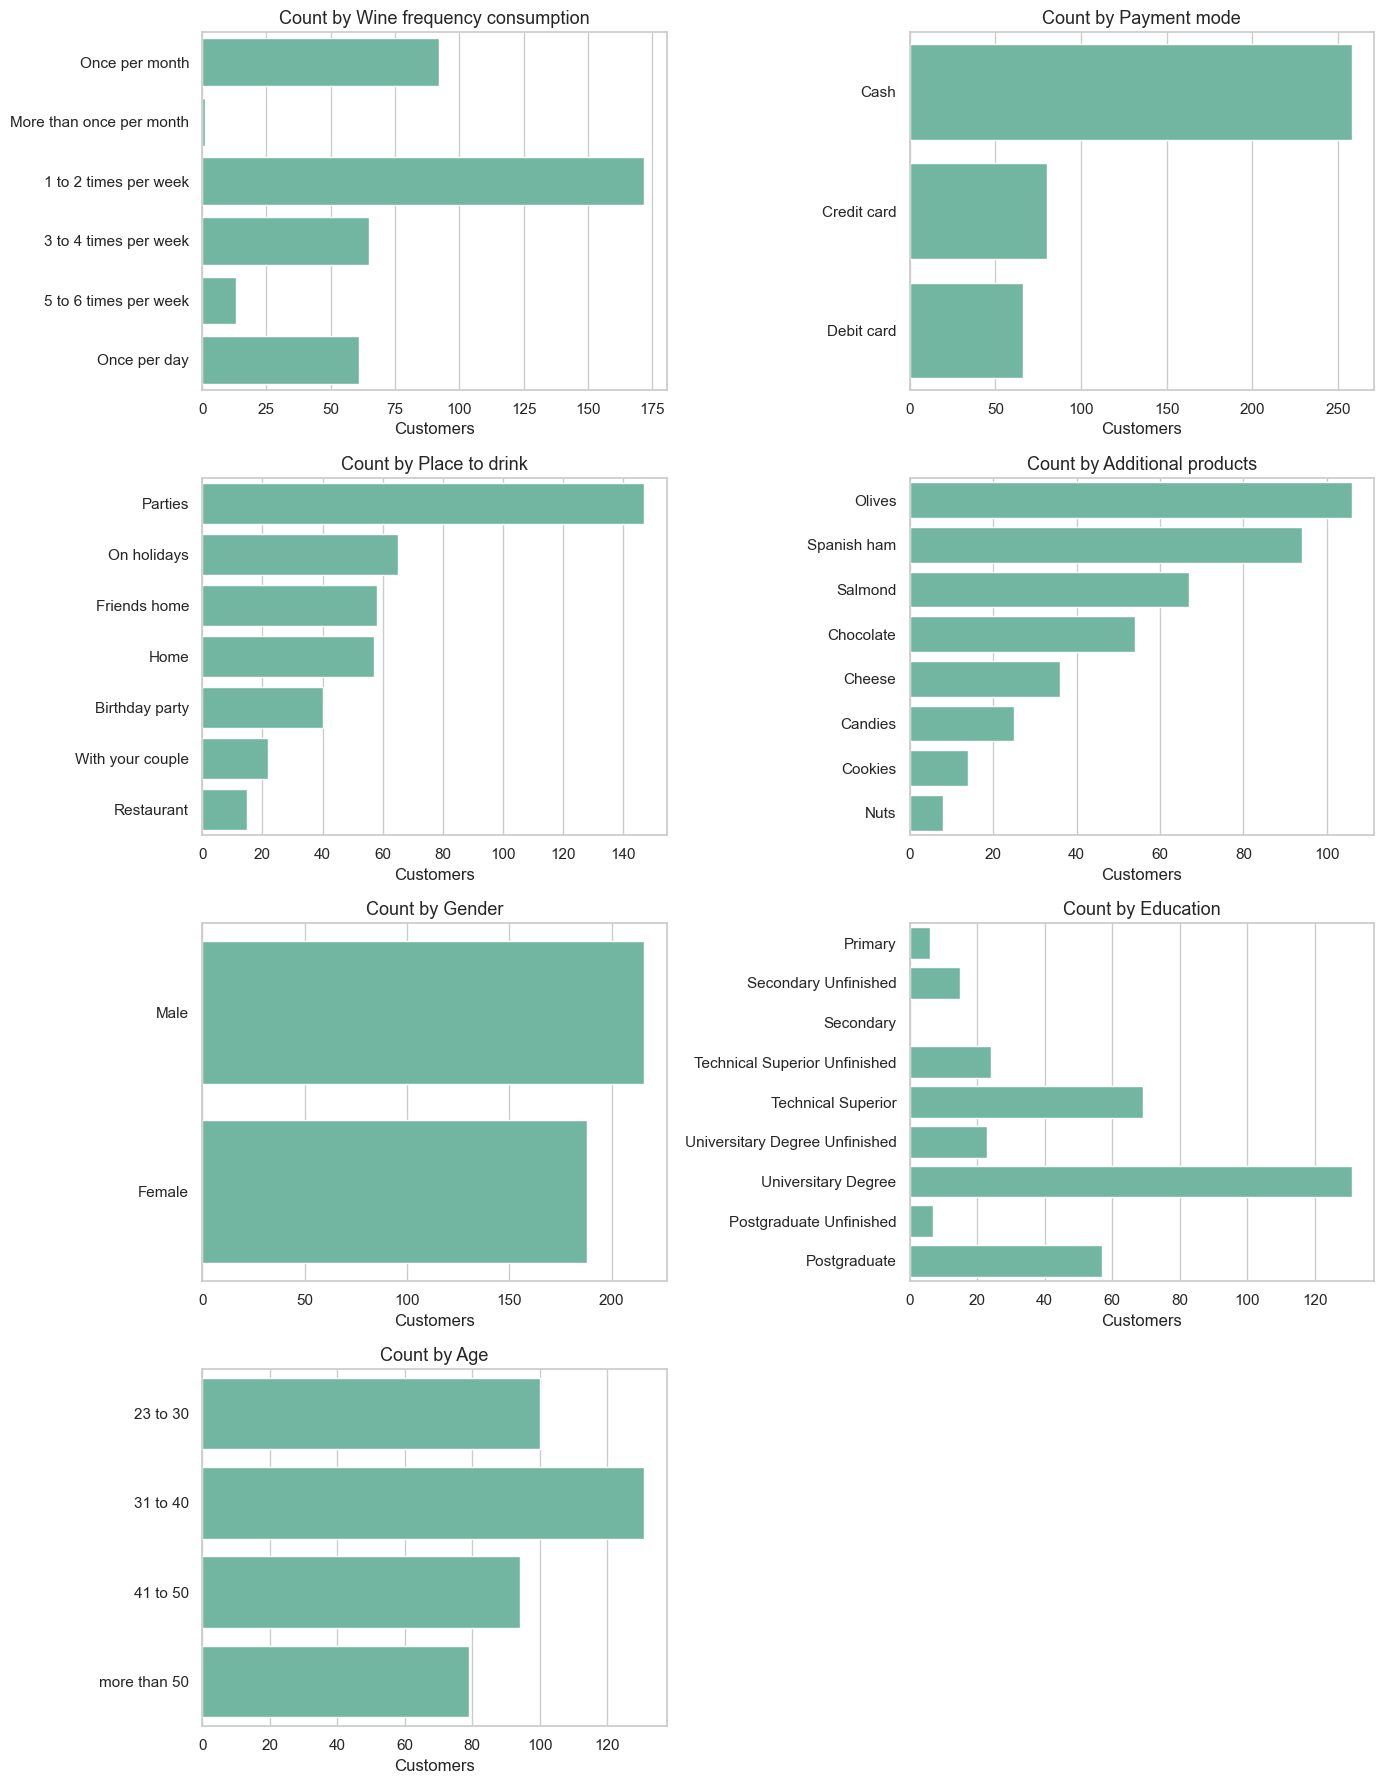

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].cat.categories if hasattr(df[col], 'cat') else df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f'Count by {col}')
    ax.set_xlabel('Customers'); ax.set_ylabel('')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

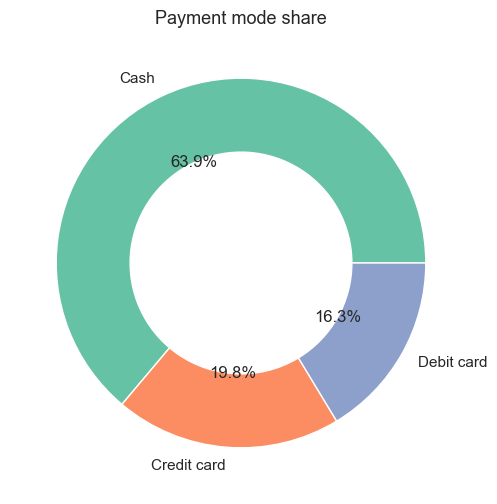

In [5]:
# Donut for payment mode (good for a 3-category share view)
fig, ax = plt.subplots(figsize=(6, 6))
vc = df['Payment mode'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       wedgeprops=dict(width=0.4), colors=sns.color_palette('Set2'))
ax.set_title('Payment mode share')
plt.show()

## 4. Univariate — Ticket (numeric)

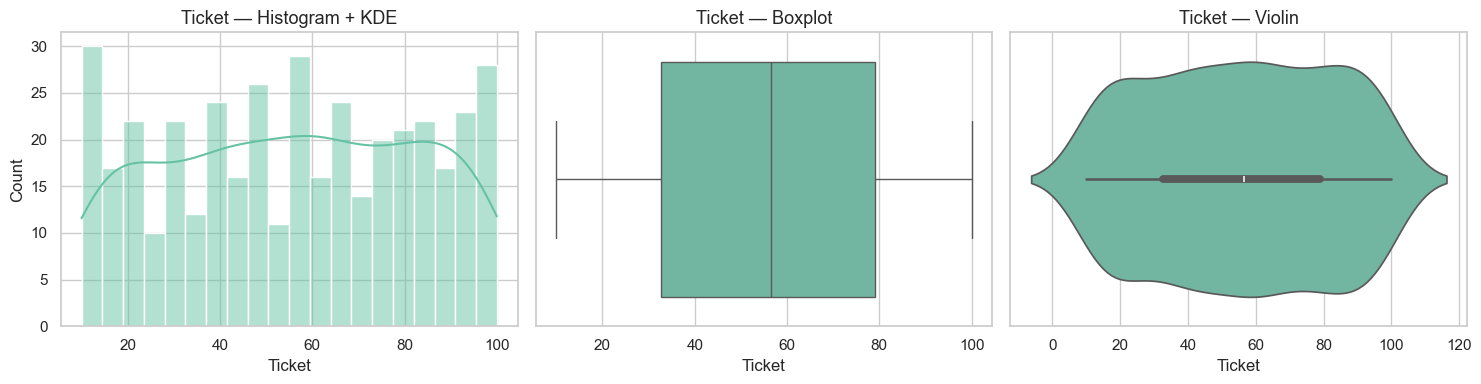

count    404.000000
mean      55.698020
std       26.949966
min       10.000000
25%       32.750000
50%       56.500000
75%       79.000000
max      100.000000
Name: Ticket, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Ticket'], bins=20, kde=True, ax=axes[0]); axes[0].set_title('Ticket — Histogram + KDE')
sns.boxplot(x=df['Ticket'], ax=axes[1]); axes[1].set_title('Ticket — Boxplot')
sns.violinplot(x=df['Ticket'], ax=axes[2]); axes[2].set_title('Ticket — Violin')
plt.tight_layout(); plt.show()
df['Ticket'].describe()

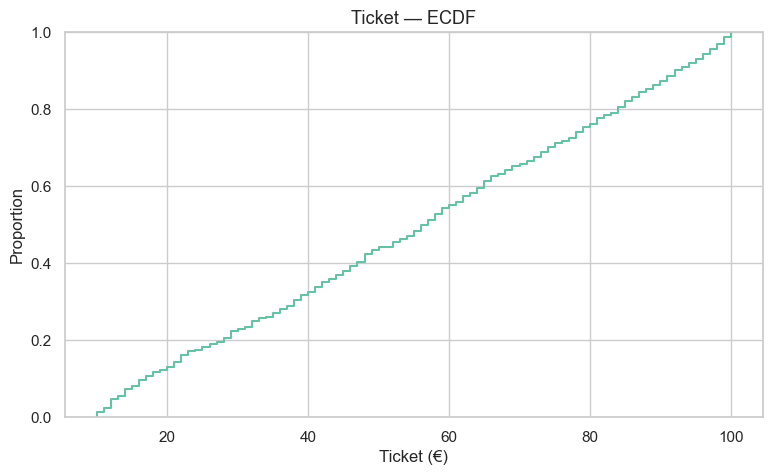

In [7]:
# Empirical CDF — what share of customers spend less than X?
fig, ax = plt.subplots()
sns.ecdfplot(df['Ticket'], ax=ax)
ax.set_title('Ticket — ECDF'); ax.set_xlabel('Ticket (€)')
plt.show()

## 5. Bivariate — Ticket vs each categorical
Where does basket value concentrate?

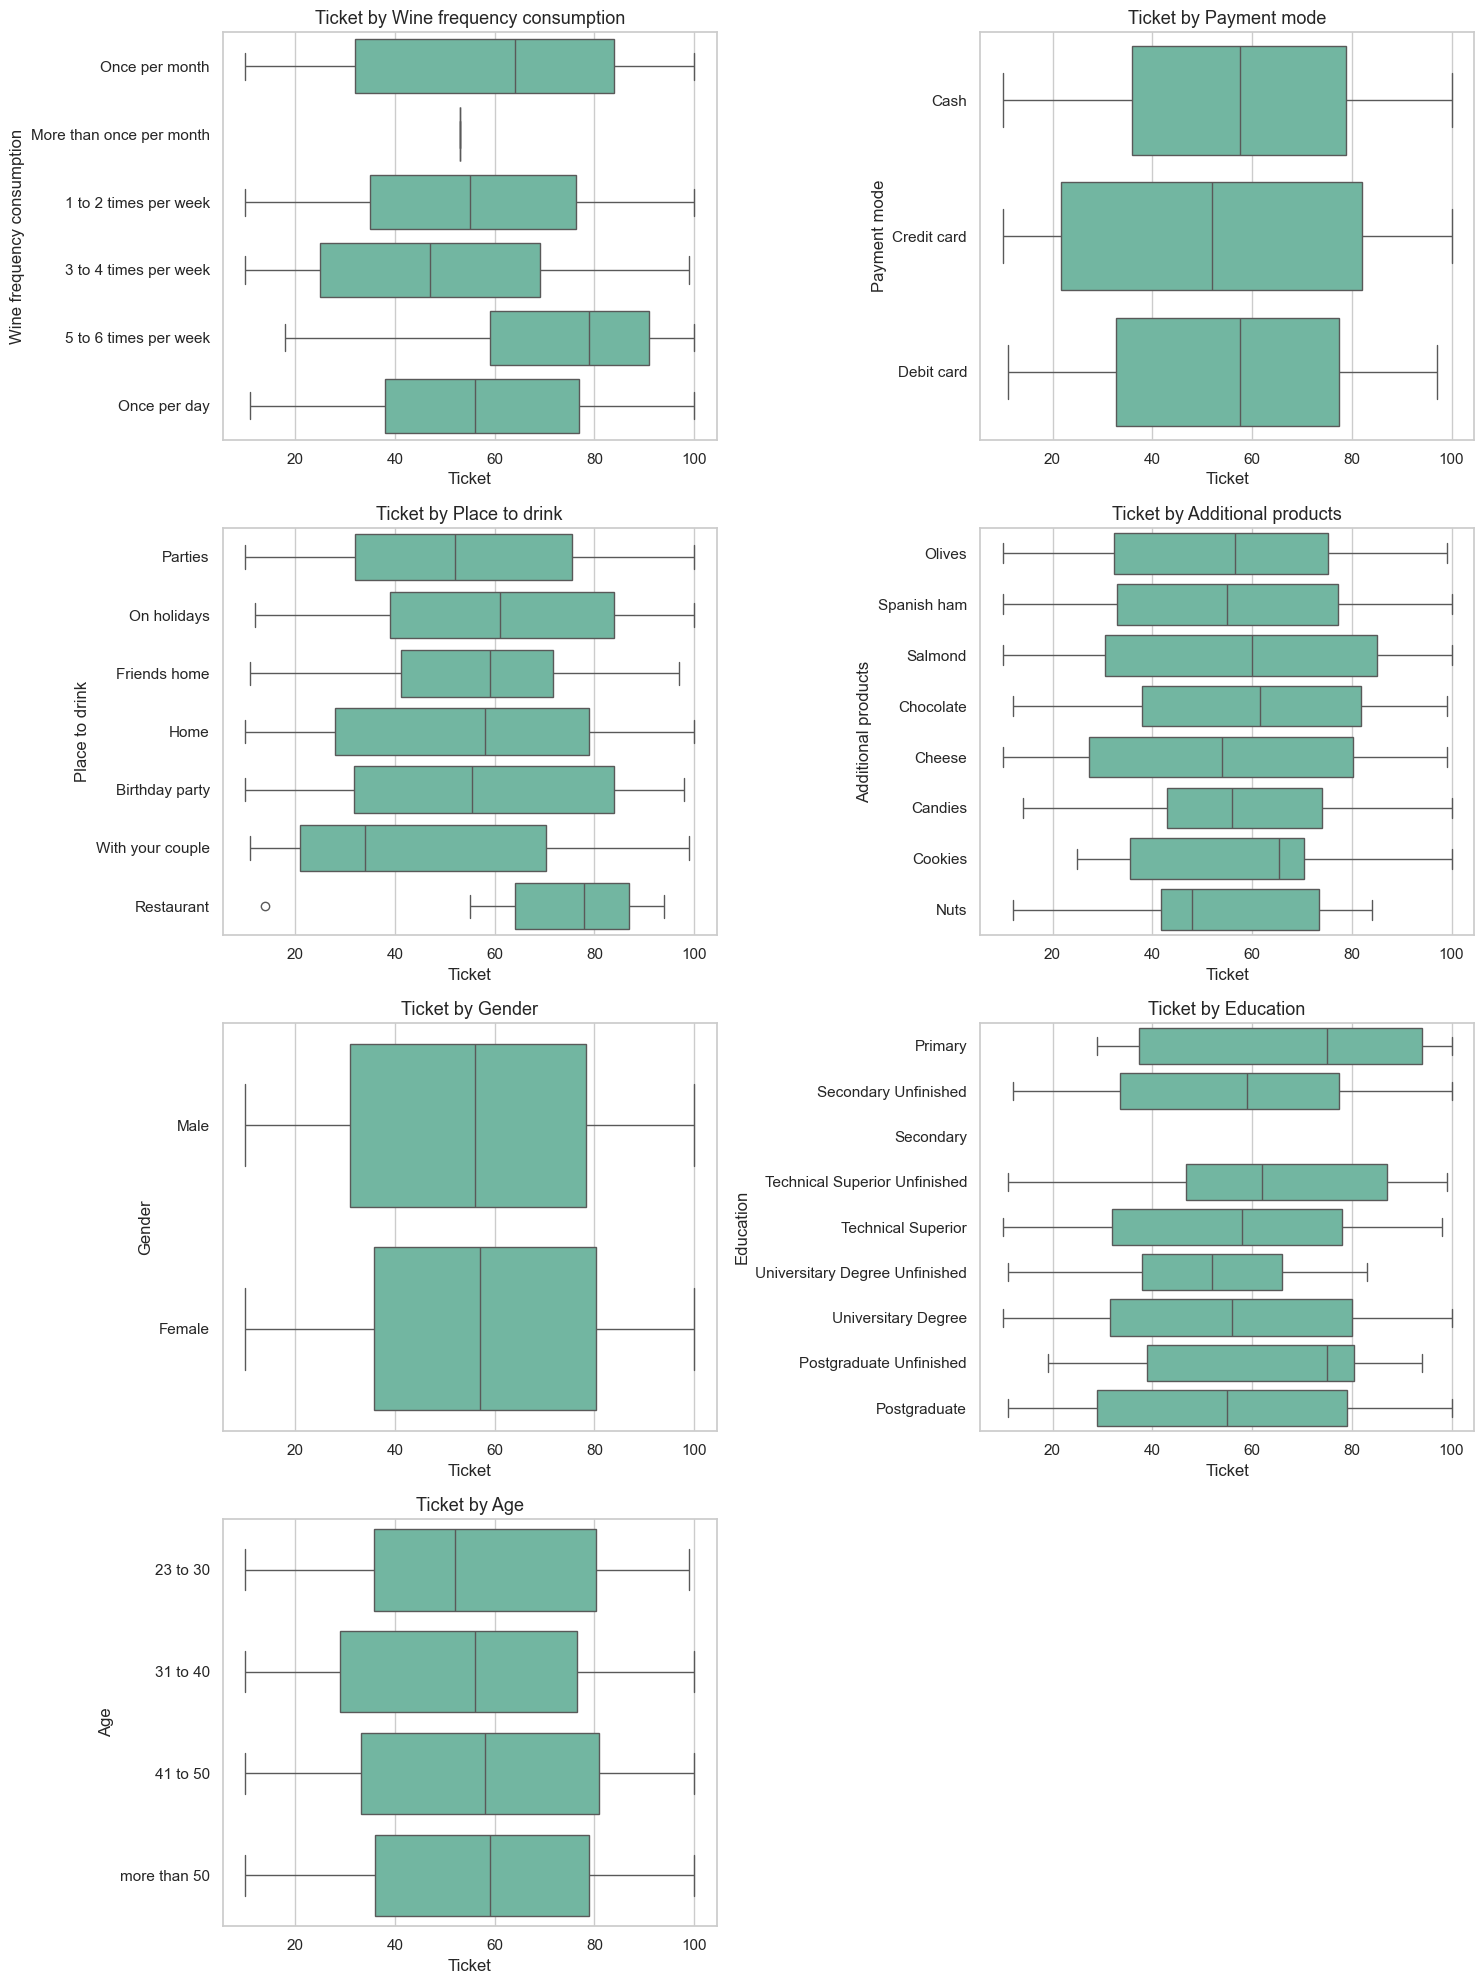

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].cat.categories if hasattr(df[col], 'cat') else df[col].value_counts().index
    sns.boxplot(data=df, y=col, x='Ticket', order=order, ax=ax)
    ax.set_title(f'Ticket by {col}')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

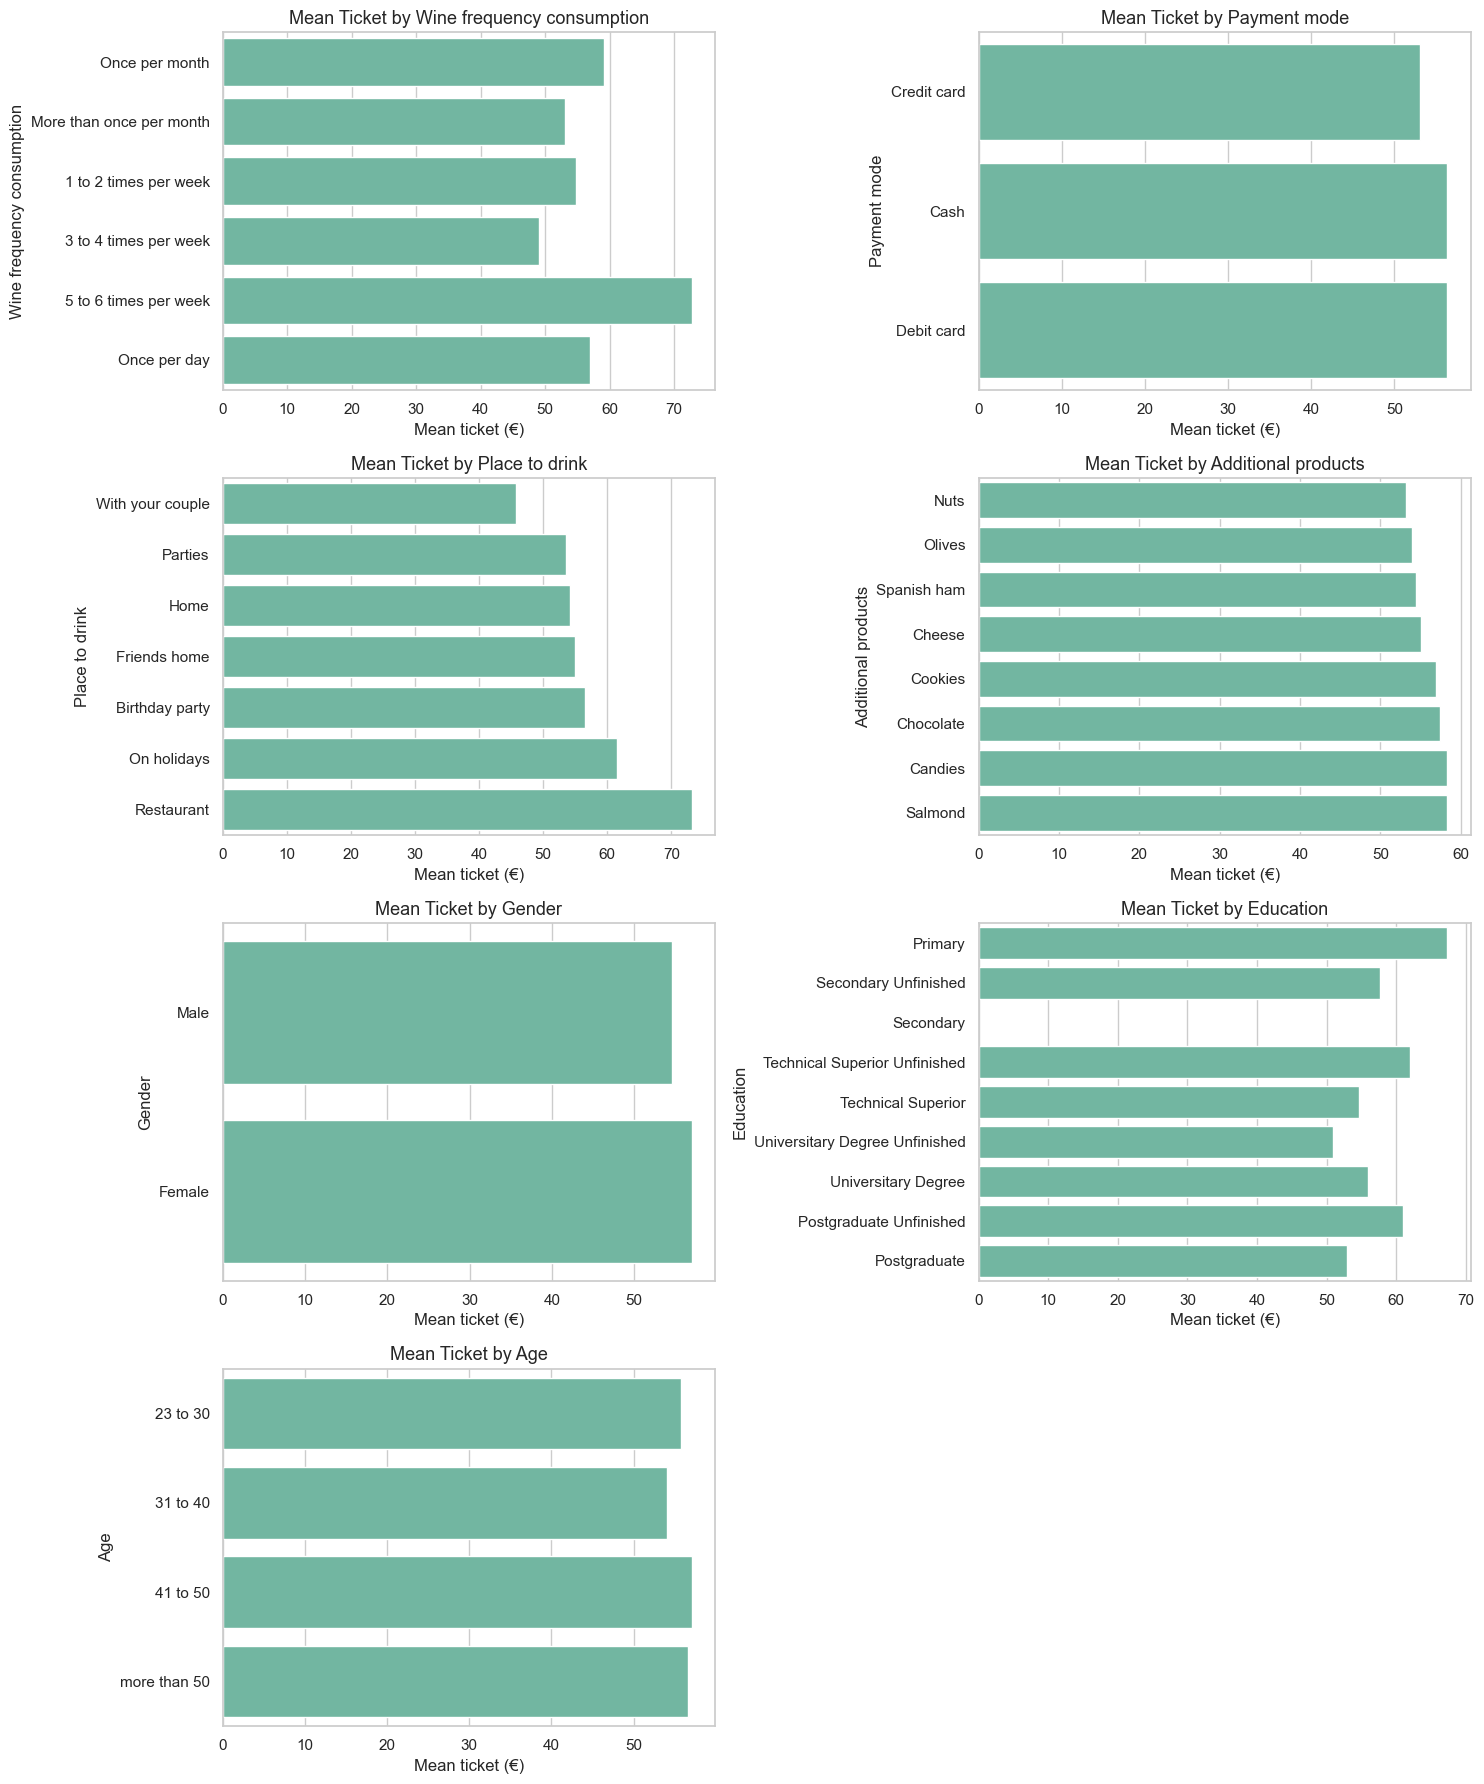

In [9]:
# Mean ticket per category — bar chart version (easier to read for the client report)
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    means = df.groupby(col, observed=True)['Ticket'].mean().sort_values()
    sns.barplot(x=means.values, y=means.index, ax=ax)
    ax.set_title(f'Mean Ticket by {col}')
    ax.set_xlabel('Mean ticket (€)')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

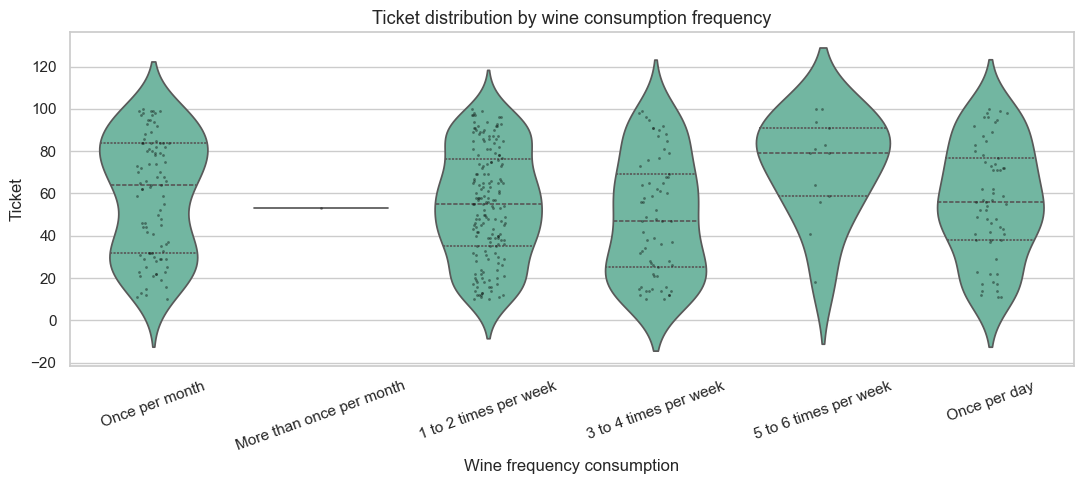

In [10]:
# Strip + violin combo for the most business-relevant split: Ticket by frequency
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=df, x='Wine frequency consumption', y='Ticket',
               order=freq_order, inner='quartile', ax=ax)
sns.stripplot(data=df, x='Wine frequency consumption', y='Ticket',
              order=freq_order, color='black', size=2, alpha=0.4, ax=ax)
ax.set_title('Ticket distribution by wine consumption frequency')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 6. Bivariate — Categorical vs Categorical
Cross-tabs as heatmaps and stacked bars.

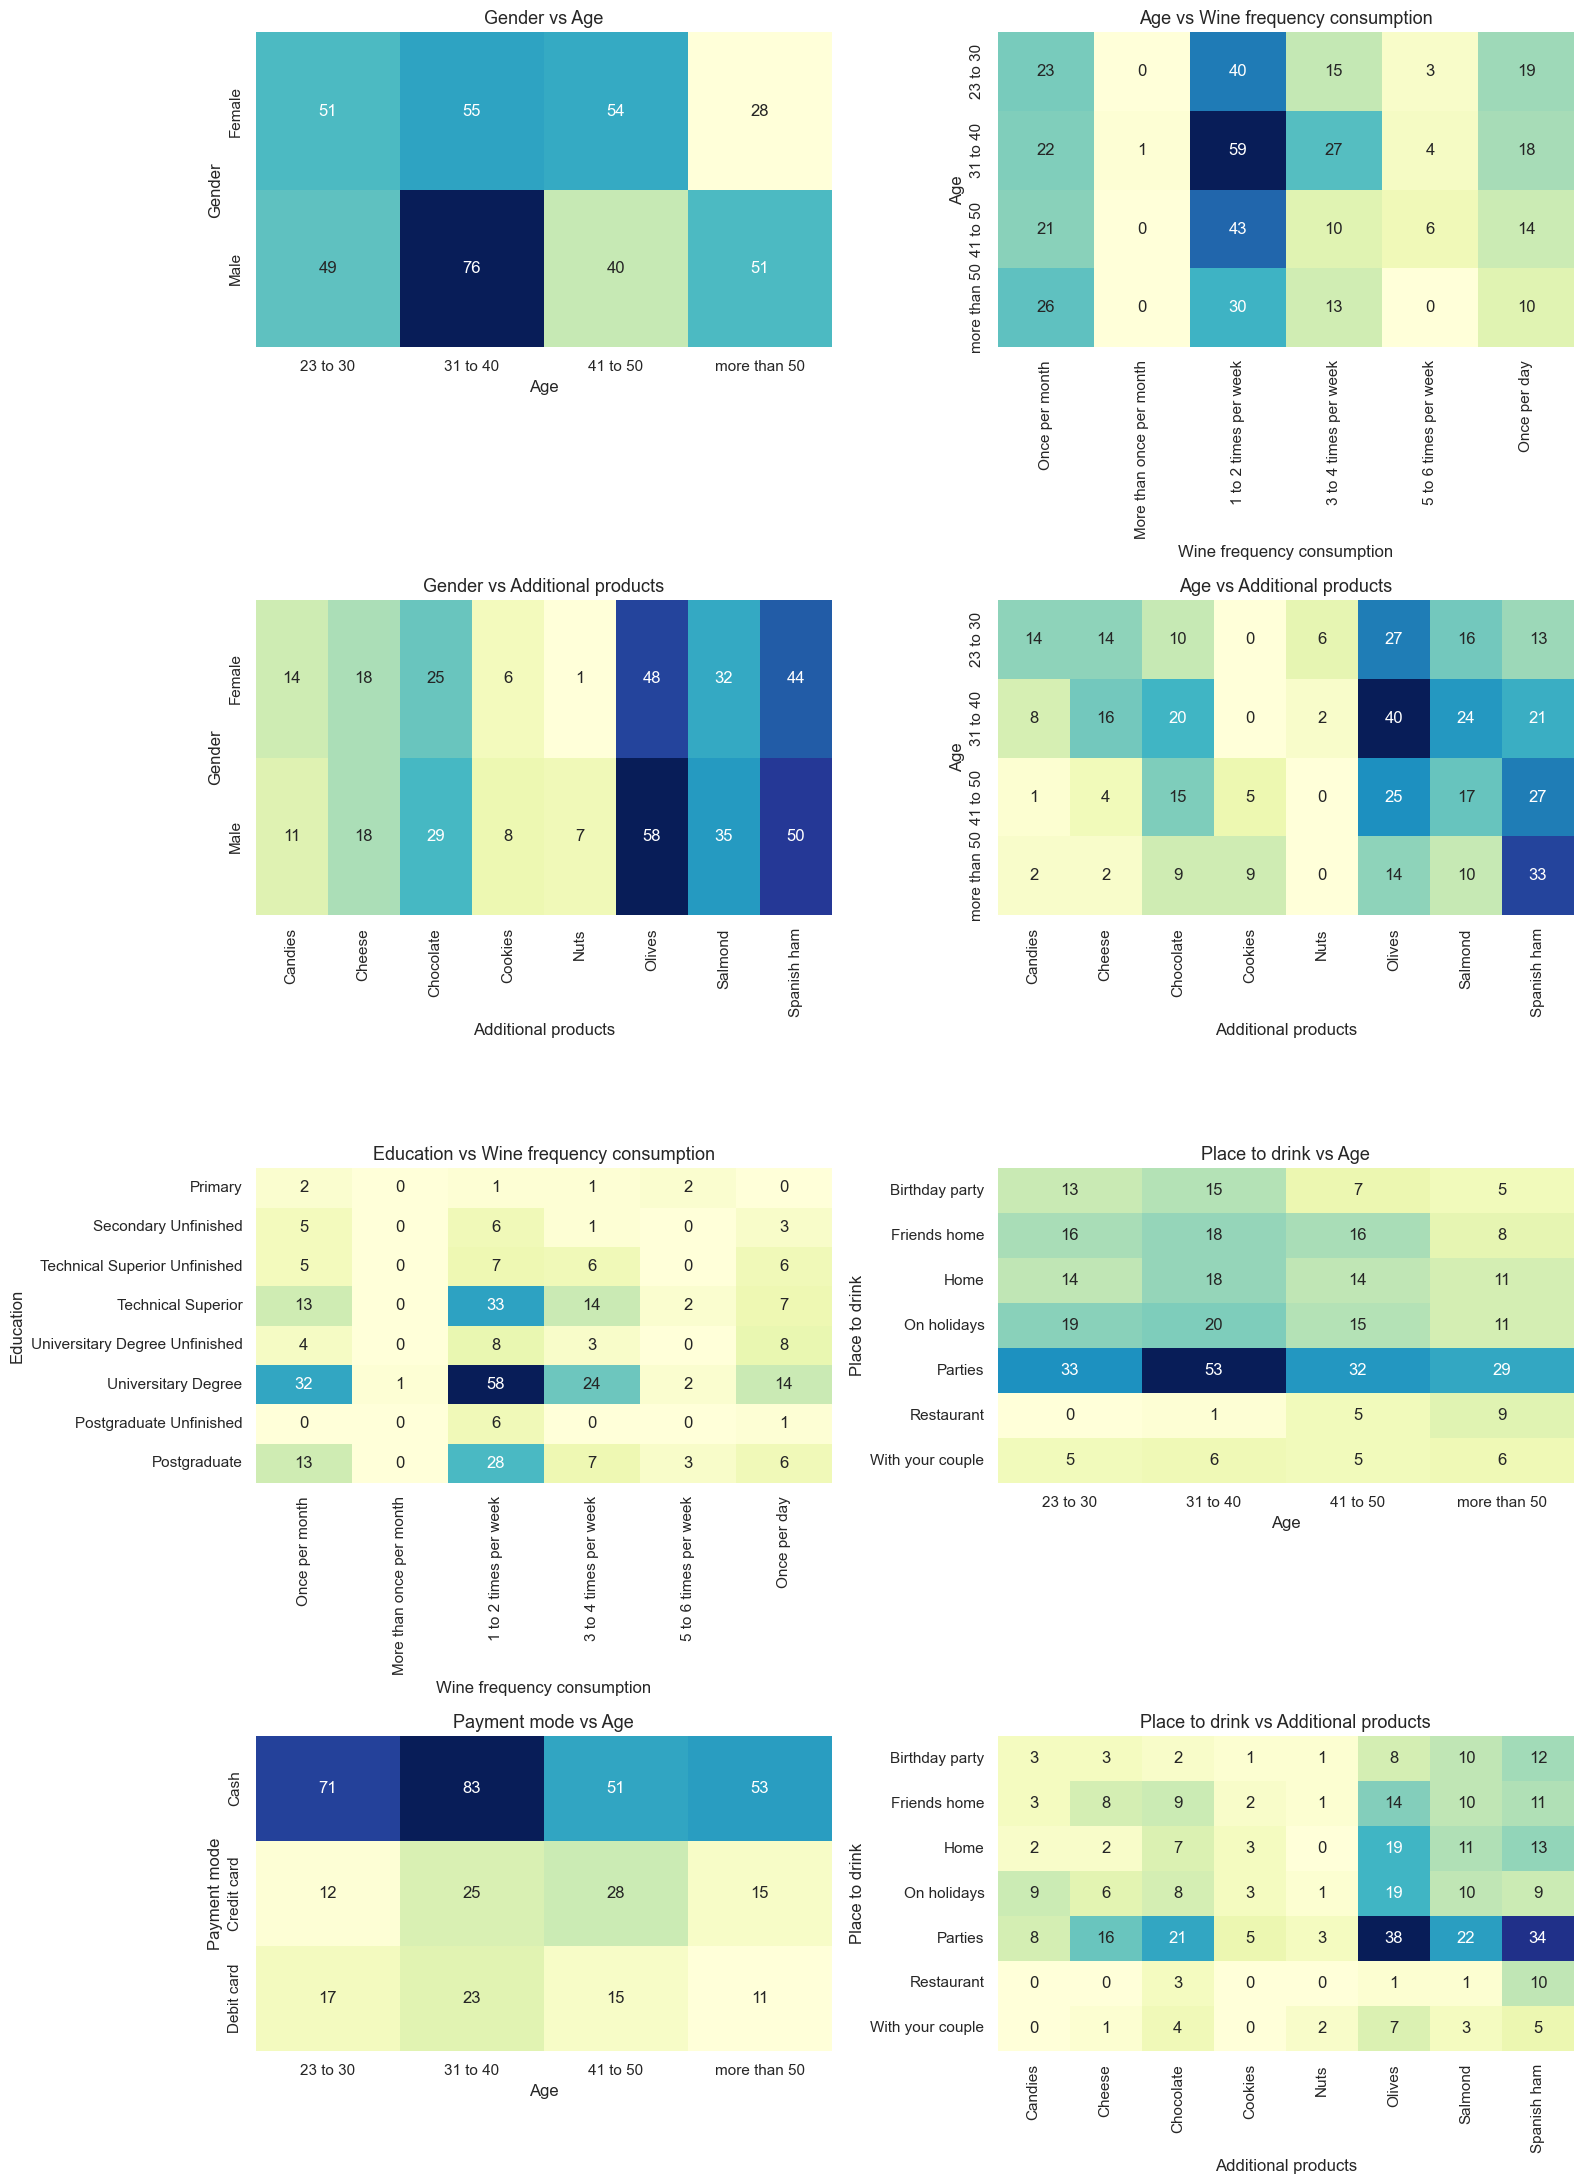

In [11]:
pairs = [
    ('Gender', 'Age'),
    ('Age', 'Wine frequency consumption'),
    ('Gender', 'Additional products'),
    ('Age', 'Additional products'),
    ('Education', 'Wine frequency consumption'),
    ('Place to drink', 'Age'),
    ('Payment mode', 'Age'),
    ('Place to drink', 'Additional products'),
]
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df[a], df[b])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=ax)
    ax.set_title(f'{a} vs {b}')
plt.tight_layout(); plt.show()

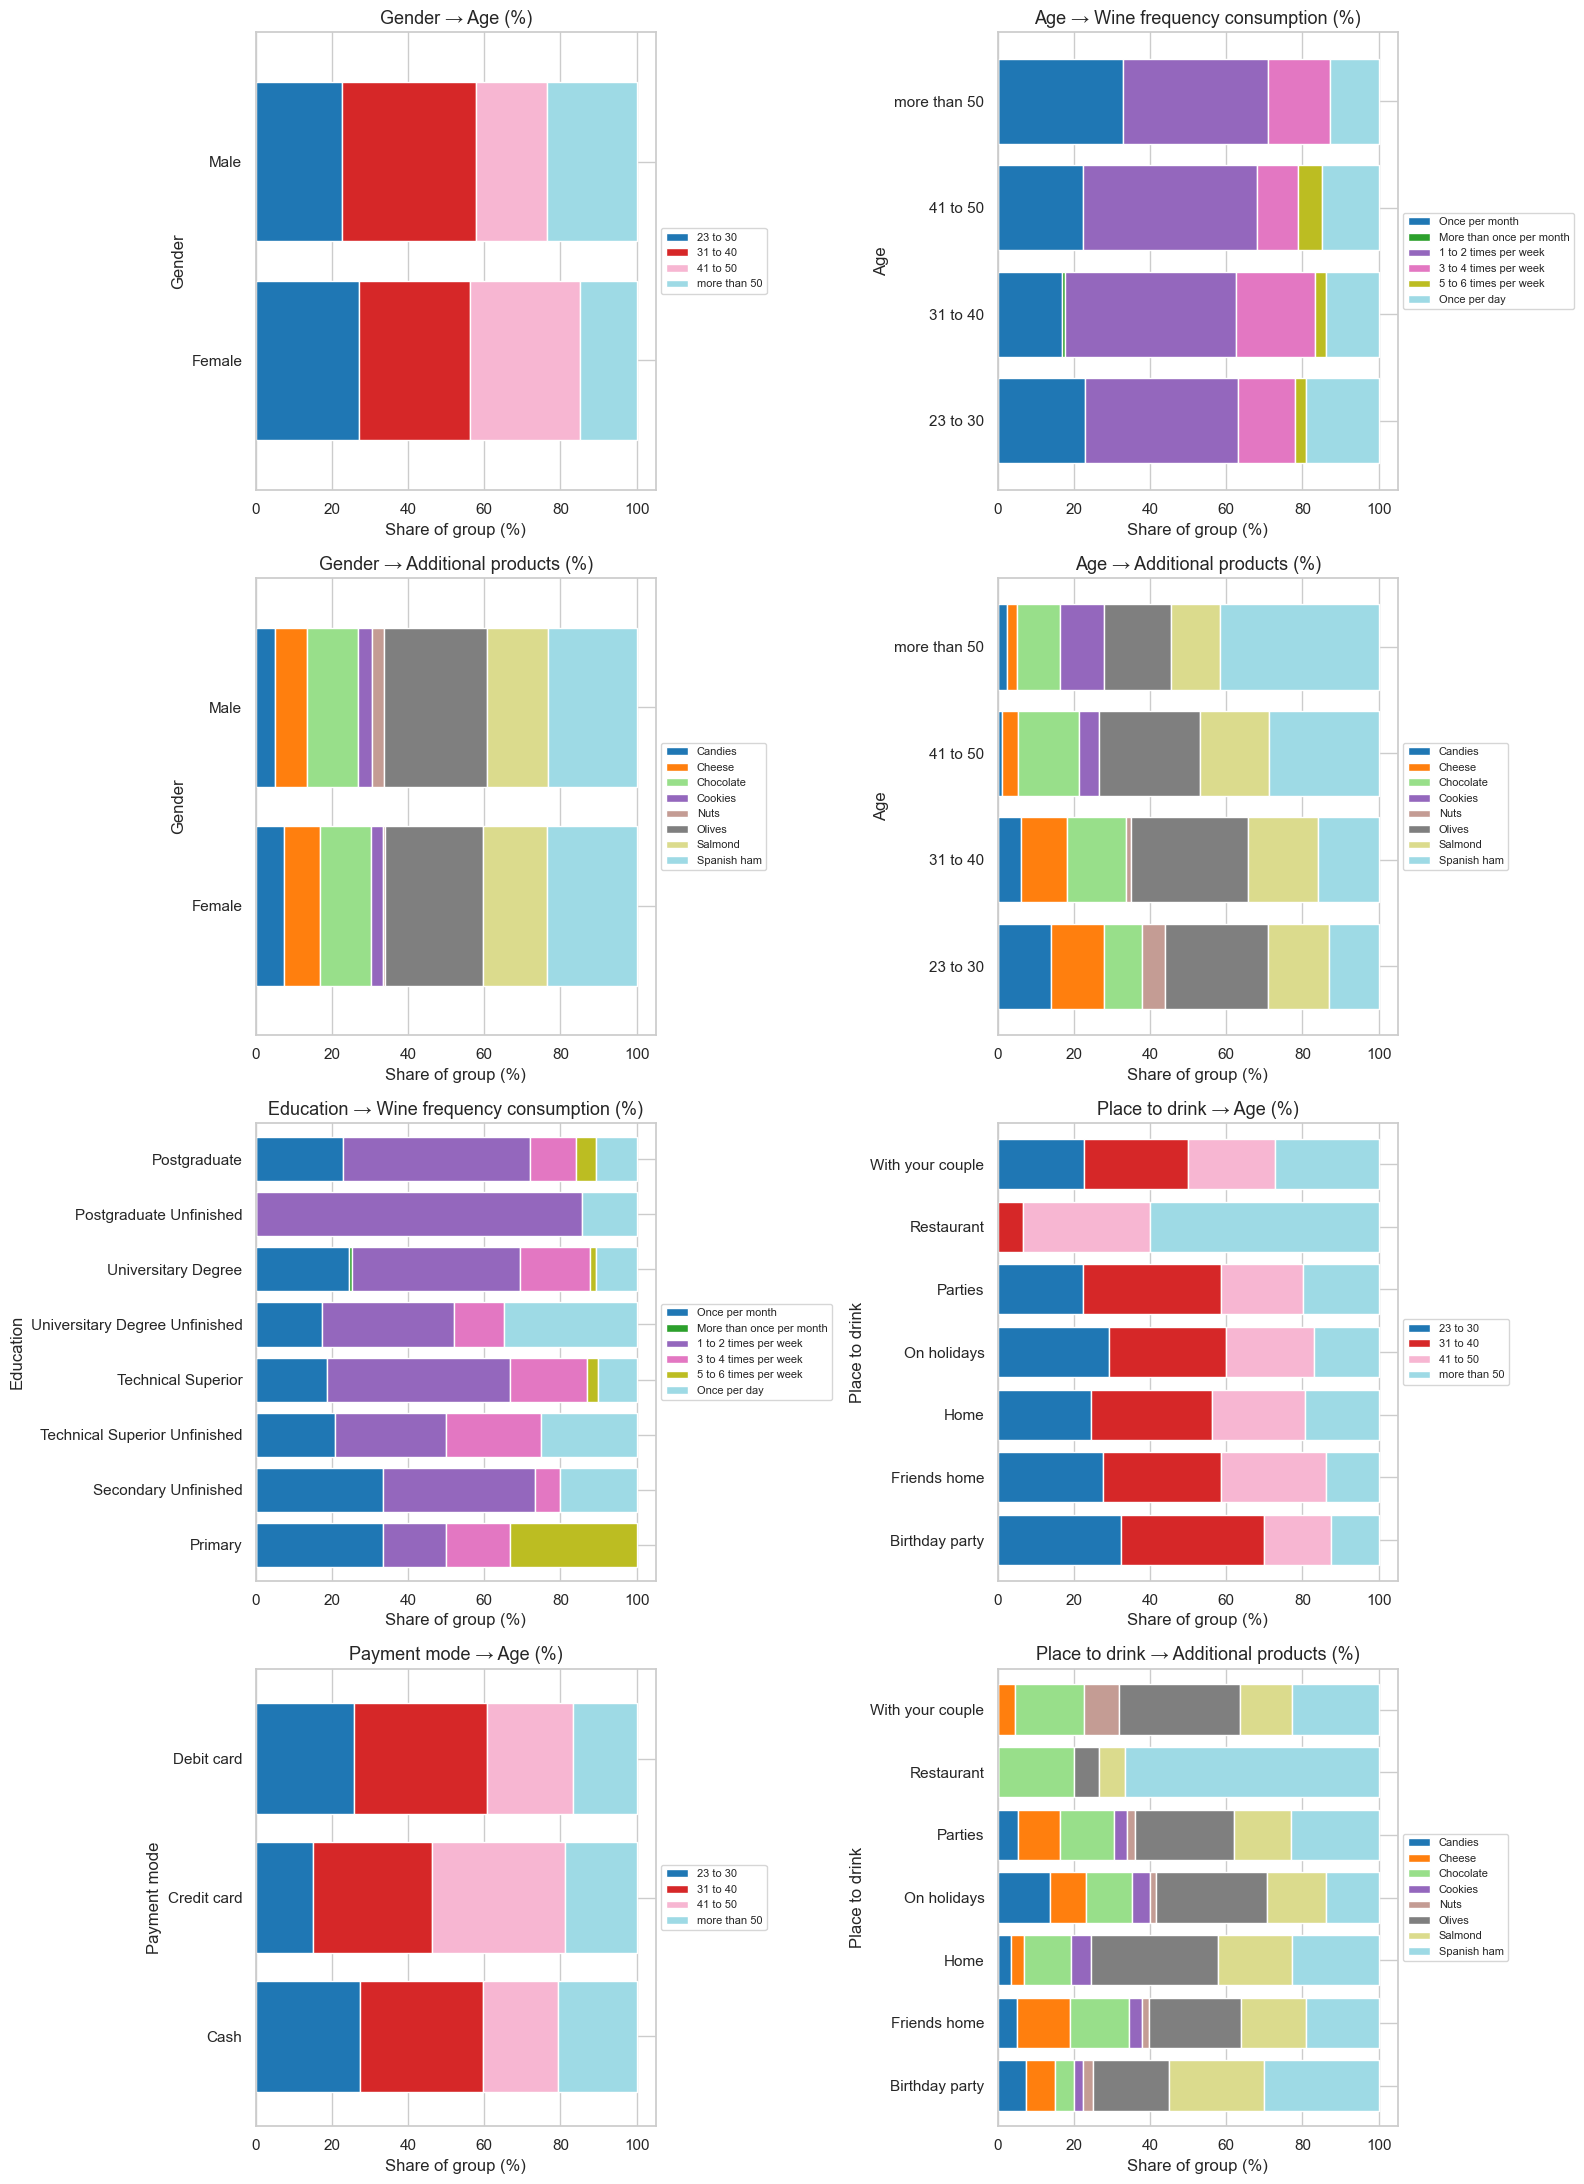

In [12]:
# Same pairs as 100% stacked bars — easier to compare proportions across groups
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df[a], df[b], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.8)
    ax.set_title(f'{a} → {b} (%)')
    ax.set_xlabel('Share of group (%)')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

## 7. Multivariate — small multiples
Ticket distribution split by Gender × Age, and grouped means.

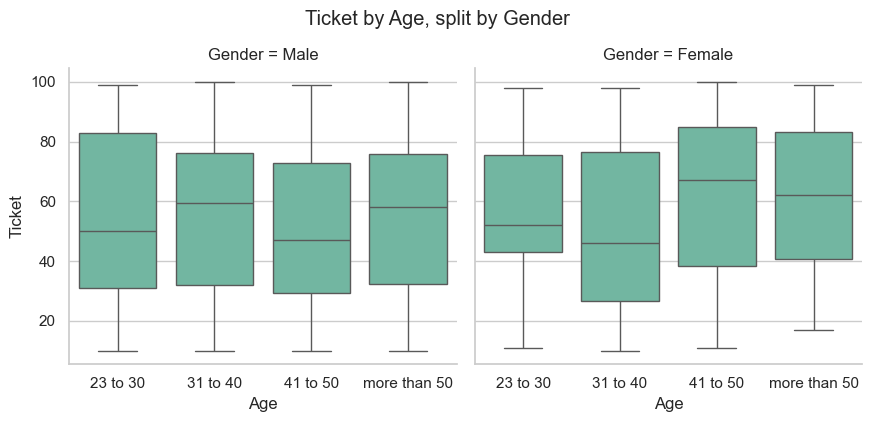

In [13]:
g = sns.catplot(data=df, kind='box', x='Age', y='Ticket', col='Gender',
                order=age_order, height=4, aspect=1.1)
g.fig.suptitle('Ticket by Age, split by Gender', y=1.05)
plt.show()

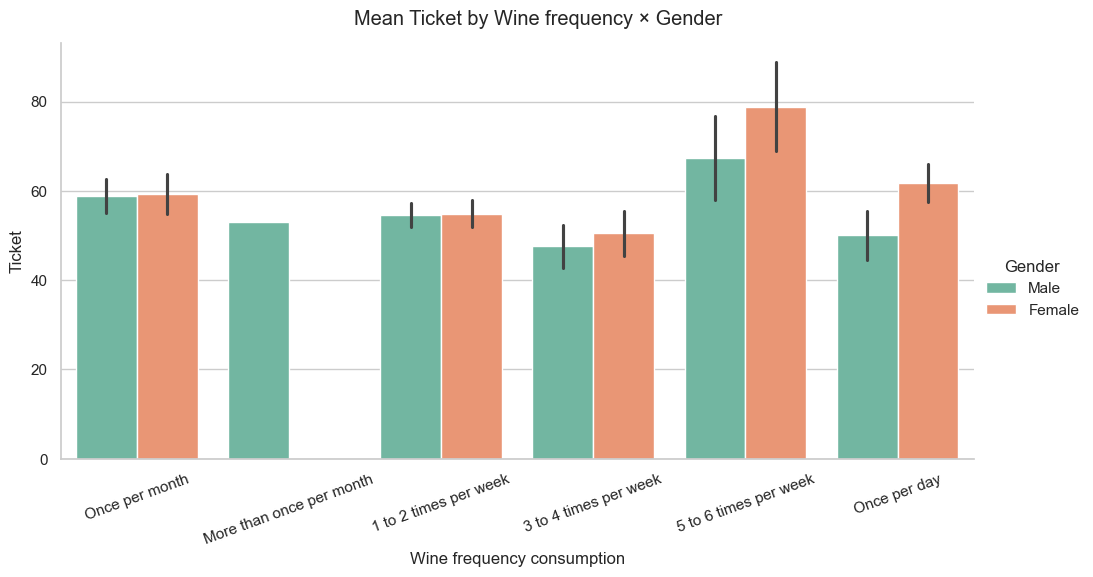

In [14]:
g = sns.catplot(data=df, kind='bar', x='Wine frequency consumption', y='Ticket',
                hue='Gender', order=freq_order, height=5, aspect=2, errorbar='se')
g.set_xticklabels(rotation=20)
g.fig.suptitle('Mean Ticket by Wine frequency × Gender', y=1.03)
plt.show()

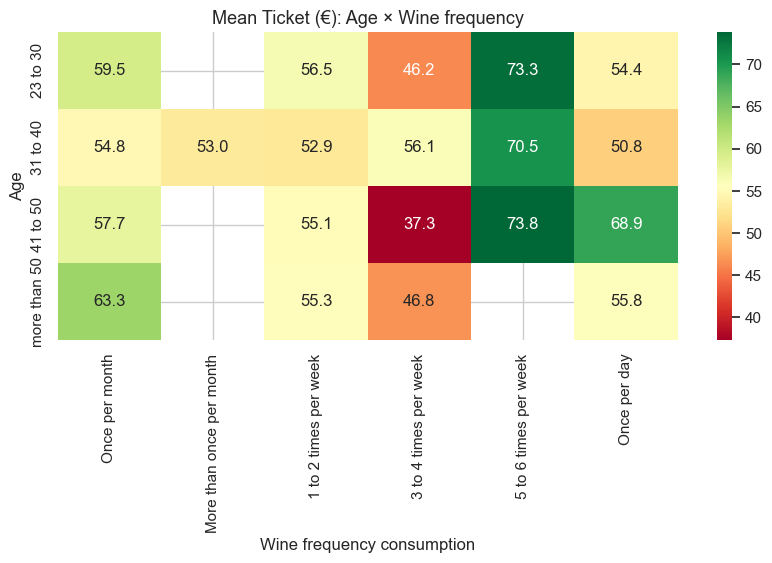

In [15]:
# Heatmap of mean ticket: Age × Wine frequency
pivot = df.pivot_table(index='Age', columns='Wine frequency consumption',
                       values='Ticket', aggfunc='mean', observed=True)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
ax.set_title('Mean Ticket (€): Age × Wine frequency')
plt.show()

## 8. Plotly — interactive visualizations (Session 3 toolkit)
Treemap, sunburst, parallel categories, Sankey-style flows.

In [16]:
# Treemap of additional products, broken down by gender
agg = df.groupby(['Additional products', 'Gender']).size().reset_index(name='count')
fig = px.treemap(agg, path=['Additional products', 'Gender'], values='count',
                 color='count', color_continuous_scale='Teal',
                 title='Additional products bought (treemap)')
fig.show()

In [17]:
# Sunburst: Age → Gender → Place to drink
agg = df.groupby(['Age', 'Gender', 'Place to drink'], observed=True).size().reset_index(name='count')
fig = px.sunburst(agg, path=['Age', 'Gender', 'Place to drink'], values='count',
                  title='Customer profile sunburst — Age → Gender → Place to drink')
fig.show()

In [18]:
# Parallel categories — see how customer profiles flow across categorical dimensions
tmp = df.dropna(subset=['Education']).copy()
tmp['Wine frequency consumption'] = tmp['Wine frequency consumption'].astype(str)
tmp['Age'] = tmp['Age'].astype(str)
fig = px.parallel_categories(
    tmp, dimensions=['Gender', 'Age', 'Wine frequency consumption', 'Payment mode'],
    color='Ticket', color_continuous_scale=px.colors.sequential.Viridis,
    title='Parallel categories — customer profile flow (color = Ticket)')
fig.show()

In [19]:
# Bar of mean ticket per Place to drink, ordered
agg = df.groupby('Place to drink')['Ticket'].agg(['mean', 'count']).reset_index().sort_values('mean')
fig = px.bar(agg, x='mean', y='Place to drink', orientation='h',
             text=agg['count'].apply(lambda x: f'n={x}'),
             title='Mean Ticket by Place to drink', labels={'mean': 'Mean ticket (€)'})
fig.show()

In [20]:
# Strip / scatter view: ticket per individual, colored by frequency, faceted by age
fig = px.strip(df, x='Wine frequency consumption', y='Ticket', color='Gender',
               facet_col='Age', category_orders={'Age': age_order, 'Wine frequency consumption': freq_order},
               title='Ticket per customer — Gender × Wine frequency, faceted by Age')
fig.update_xaxes(tickangle=30)
fig.show()

## 9. Association strength between categorical variables (Cramér's V)
A heatmap of pairwise association — analogue of correlation, but for categoricals.

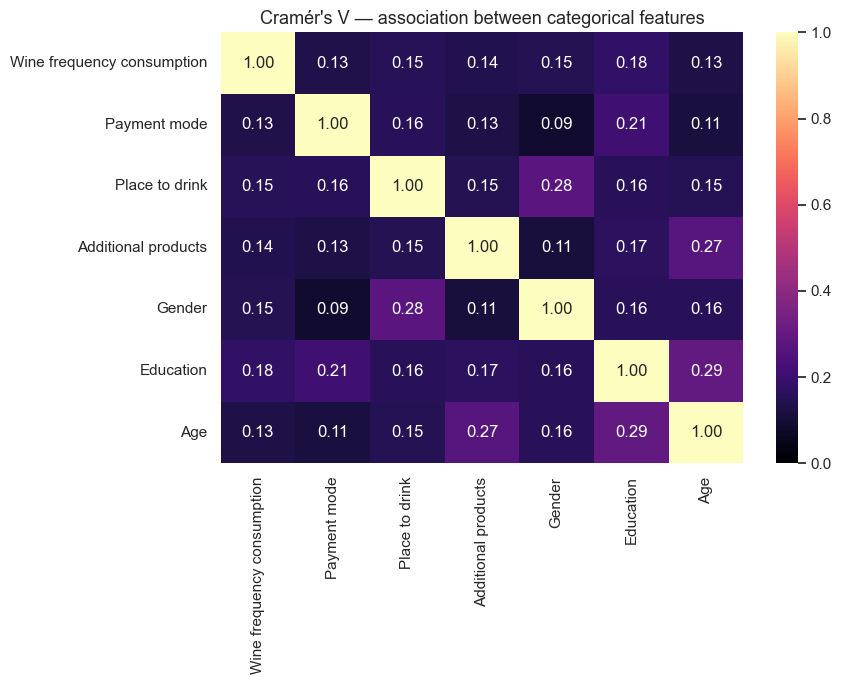

In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0: return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else np.nan

cats = cat_cols
mat = pd.DataFrame(index=cats, columns=cats, dtype=float)
for a in cats:
    for b in cats:
        mat.loc[a, b] = cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat.astype(float), annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1, ax=ax)
ax.set_title("Cramér's V — association between categorical features")
plt.tight_layout(); plt.show()

## 10. Headline takeaways (preliminary)
Items to validate in the deeper analysis / report:

1. **Customer base skews 31–50, mostly with higher education.** Marketing copy and channels should reflect that.
2. **Wine is mainly consumed at *parties / holidays / friends' homes*** — social occasions rather than at home alone. Bundles like *wine + olives + Spanish ham* fit this.
3. **Cash dominates payment (~64%)**, even with university-educated customers — point-of-sale and loyalty design should not assume card-first.
4. **Olives and Spanish ham are the top deli add-ons** — these are the natural anchors for cross-sell to fight the "perceived as a wine shop" problem.
5. **Ticket value is broadly uniform (10–100 €, mean ~56 €)** with no extreme outliers — segmentation by ticket size alone is weak; behavioral segments (frequency × occasion × add-on) look more promising.
6. **Cramér's V** flags which categorical pairs deserve a deeper look (e.g. Age ↔ Frequency, Place ↔ Additional product) for the segmentation step.